# Week 3 · Lecture 2 — Gibbs Sampling

## Learning objectives

1. State the **Gibbs sampler** as a special case of Metropolis–Hastings with proposal equal to the full conditional, giving acceptance probability one.
2. Derive the full conditionals for a Bayesian Gaussian model with unknown mean and variance (the textbook NIG example).
3. Implement Gibbs sampling for a **mixture of Gaussians** with conjugate priors — a non-trivial latent-variable model that brings out the strength of Gibbs.
4. Diagnose **label switching** and **mode trapping** in Gibbs.

## 1. From MH to Gibbs

Partition $\theta = (\theta_1, \dots, \theta_K)$. At each Gibbs step, update one block $\theta_k$ by sampling

$$
\theta_k^{(t+1)} \sim p(\theta_k \mid \theta_{-k}^{(t)},\ \mathcal{D}),
$$

where $\theta_{-k}$ are the remaining blocks. The MH acceptance probability with proposal $q = p(\theta_k \mid \theta_{-k}, \mathcal{D})$ algebraically reduces to 1 — we never reject. This requires that we can sample from each full conditional, which often demands conjugate priors block by block.

## 2. Worked example: Bayesian Gaussian with NIG prior

Data $x_1, \dots, x_N \sim \mathcal{N}(\mu, \sigma^2)$, both unknown. Conjugate joint prior NIG (Week 1, Lecture 2). The two full conditionals are:

$$
\mu \mid \sigma^2, \mathcal{D} \;\sim\; \mathcal{N}\!\left(\,\tfrac{\kappa_0 m_0 + N \bar x}{\kappa_0 + N},\ \tfrac{\sigma^2}{\kappa_0 + N}\right),
$$
$$
\sigma^2 \mid \mu, \mathcal{D} \;\sim\; \mathrm{InvGamma}\!\left(a_0 + \tfrac{N}{2},\ b_0 + \tfrac{1}{2}\sum_i (x_i - \mu)^2 + \tfrac{\kappa_0}{2}(\mu - m_0)^2\right).
$$

(The second conditional uses the joint NIG; for an independent prior $p(\mu)p(\sigma^2)$ the cross term in $b$ vanishes.) We alternate between these two updates.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


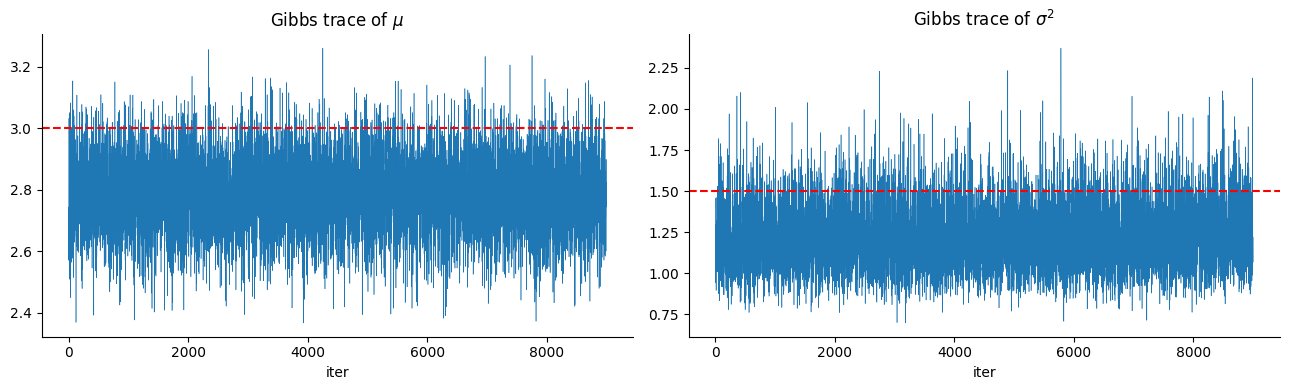

E[mu | D]    = 2.7846   (truth 3.0)
E[sigma^2|D] = 1.2202   (truth 1.5)


In [2]:
def gibbs_normal_nig(x, m0=0.0, kappa0=0.01, a0=0.5, b0=0.5, n_iter=10_000, rng=None):
    rng = rng or np.random.default_rng(0)
    N = len(x)
    xbar = x.mean()
    mu = xbar
    sigma2 = x.var()

    samples = np.empty((n_iter, 2))
    for t in range(n_iter):
        # mu | sigma2
        mu_mean = (kappa0 * m0 + N * xbar) / (kappa0 + N)
        mu_var = sigma2 / (kappa0 + N)
        mu = rng.normal(mu_mean, np.sqrt(mu_var))

        # sigma2 | mu
        a_post = a0 + N / 2
        b_post = b0 + 0.5 * np.sum((x - mu)**2) + 0.5 * kappa0 * (mu - m0)**2
        sigma2 = stats.invgamma.rvs(a_post, scale=b_post, random_state=rng)

        samples[t] = (mu, sigma2)
    return samples


rng = np.random.default_rng(7)
true_mu, true_sigma2 = 3.0, 1.5
x = rng.normal(true_mu, np.sqrt(true_sigma2), size=80)
samples = gibbs_normal_nig(x, n_iter=10_000, rng=rng)
samples = samples[1000:]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(samples[:, 0], lw=0.4); axes[0].axhline(true_mu, color="red", ls="--")
axes[0].set_title(r"Gibbs trace of $\mu$"); axes[0].set_xlabel("iter")

axes[1].plot(samples[:, 1], lw=0.4); axes[1].axhline(true_sigma2, color="red", ls="--")
axes[1].set_title(r"Gibbs trace of $\sigma^2$"); axes[1].set_xlabel("iter")
plt.tight_layout(); plt.show()

print(f"E[mu | D]    = {samples[:,0].mean():.4f}   (truth {true_mu})")
print(f"E[sigma^2|D] = {samples[:,1].mean():.4f}   (truth {true_sigma2})")


## 3. Gibbs for a mixture of Gaussians

Now the showcase. The mixture of $K$ Gaussians,

$$
p(x_i \mid \pi, \mu, \sigma^2) = \sum_{k=1}^K \pi_k\, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2),
$$

has *latent* mixture assignments $z_i \in \{1, \dots, K\}$. Conditioning on $z_i$ collapses the posterior into conjugate updates per cluster. This is the canonical setting where Gibbs shines.

We use conjugate priors:
- $\pi \sim \mathrm{Dirichlet}(\alpha_0, \dots, \alpha_0)$
- $\mu_k \sim \mathcal{N}(m_0, s_0^2)$
- $\sigma_k^2 \sim \mathrm{InvGamma}(a_0, b_0)$
- $z_i \sim \mathrm{Categorical}(\pi)$

The full conditionals are:
$$
p(z_i = k \mid \cdot) \propto \pi_k\, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2),
$$
$$
\pi \mid z \sim \mathrm{Dirichlet}(\alpha_0 + n_1, \dots, \alpha_0 + n_K), \quad n_k = \#\{i : z_i = k\},
$$
$$
\mu_k \mid \cdot \sim \mathcal{N}\!\left(\,\tfrac{m_0 / s_0^2 + \bar x_k n_k / \sigma_k^2}{1/s_0^2 + n_k/\sigma_k^2},\ \left(\tfrac{1}{s_0^2} + \tfrac{n_k}{\sigma_k^2}\right)^{-1}\right),
$$
$$
\sigma_k^2 \mid \cdot \sim \mathrm{InvGamma}\!\left(a_0 + n_k/2,\ b_0 + \tfrac{1}{2}\sum_{i:z_i=k}(x_i - \mu_k)^2\right).
$$

All are easy to sample from.


Posterior means: [-4.06325529 -0.00642936  4.94224021]
Posterior sigmas: [0.60023966 0.76480315 0.94376851]
Posterior pis:   [0.22592167 0.26974275 0.50433558]


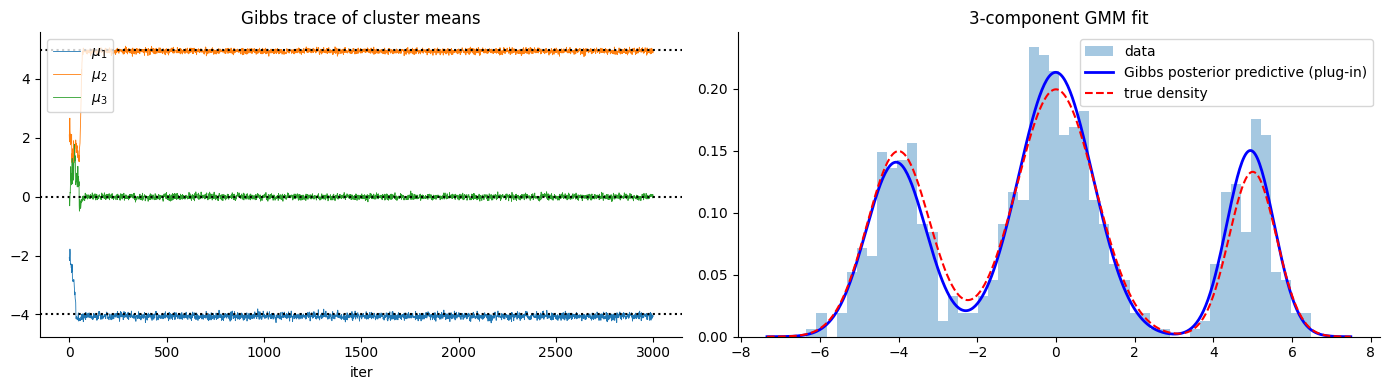

In [3]:
def gibbs_gmm(x, K, n_iter=4000, alpha0=1.0, m0=0.0, s0_sq=10.0, a0=2.0, b0=2.0, rng=None):
    rng = rng or np.random.default_rng(0)
    N = len(x)

    # Initialise
    pi = np.full(K, 1.0 / K)
    mu = rng.normal(m0, np.sqrt(s0_sq), size=K)
    sigma2 = np.full(K, x.var())
    z = rng.integers(0, K, size=N)

    trace = {"pi": [], "mu": [], "sigma2": []}
    for t in range(n_iter):
        # Sample z
        log_resp = np.log(pi)[None, :] - 0.5 * np.log(2 * np.pi * sigma2)[None, :] \
                    - 0.5 * (x[:, None] - mu[None, :])**2 / sigma2[None, :]
        log_resp -= log_resp.max(axis=1, keepdims=True)
        resp = np.exp(log_resp); resp /= resp.sum(axis=1, keepdims=True)
        cdf = np.cumsum(resp, axis=1)
        u = rng.uniform(size=(N, 1))
        z = (u < cdf).argmax(axis=1)

        # Sample pi
        counts = np.bincount(z, minlength=K)
        pi = rng.dirichlet(alpha0 + counts)

        # Sample mu_k and sigma2_k
        for k in range(K):
            mask = (z == k)
            nk = mask.sum()
            if nk == 0:
                # resample from prior so empty clusters do not collapse
                mu[k] = rng.normal(m0, np.sqrt(s0_sq))
                sigma2[k] = stats.invgamma.rvs(a0, scale=b0, random_state=rng)
                continue
            xk = x[mask]
            xbar_k = xk.mean()
            mu_var = 1.0 / (1.0 / s0_sq + nk / sigma2[k])
            mu_mean = mu_var * (m0 / s0_sq + xbar_k * nk / sigma2[k])
            mu[k] = rng.normal(mu_mean, np.sqrt(mu_var))
            a_post = a0 + nk / 2
            b_post = b0 + 0.5 * np.sum((xk - mu[k])**2)
            sigma2[k] = stats.invgamma.rvs(a_post, scale=b_post, random_state=rng)

        trace["pi"].append(pi.copy())
        trace["mu"].append(mu.copy())
        trace["sigma2"].append(sigma2.copy())

    return {k: np.array(v) for k, v in trace.items()}


# Generate mixture data
rng = np.random.default_rng(0)
N = 600
true_pi = np.array([0.3, 0.5, 0.2])
true_mu = np.array([-4, 0, 5])
true_sigma = np.array([0.8, 1.0, 0.6])
z_true = rng.choice(3, size=N, p=true_pi)
x = rng.normal(true_mu[z_true], true_sigma[z_true])

trace = gibbs_gmm(x, K=3, n_iter=3000, rng=rng)
burn = 500

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Trace of mu
for k in range(3):
    axes[0].plot(trace["mu"][:, k], lw=0.6, label=f"$\\mu_{k+1}$")
for tm in true_mu:
    axes[0].axhline(tm, color="black", ls=":")
axes[0].set_title("Gibbs trace of cluster means")
axes[0].set_xlabel("iter"); axes[0].legend()

# Density
mu_post = trace["mu"][burn:].mean(0)
sigma2_post = trace["sigma2"][burn:].mean(0)
pi_post = trace["pi"][burn:].mean(0)
print(f"Posterior means: {np.sort(mu_post)}")
print(f"Posterior sigmas: {np.sort(np.sqrt(sigma2_post))}")
print(f"Posterior pis:   {np.sort(pi_post)}")

xs = np.linspace(x.min() - 1, x.max() + 1, 500)
density = sum(pi_post[k] * stats.norm.pdf(xs, mu_post[k], np.sqrt(sigma2_post[k])) for k in range(3))
true_density = sum(true_pi[k] * stats.norm.pdf(xs, true_mu[k], true_sigma[k]) for k in range(3))

axes[1].hist(x, bins=50, density=True, alpha=0.4, label="data")
axes[1].plot(xs, density, "b-", lw=2, label="Gibbs posterior predictive (plug-in)")
axes[1].plot(xs, true_density, "r--", lw=1.5, label="true density")
axes[1].set_title("3-component GMM fit"); axes[1].legend()
plt.tight_layout(); plt.show()


## 4. Label switching

Look at the trace of $\mu_1, \mu_2, \mu_3$. The labels $k = 1, 2, 3$ are *exchangeable* — the posterior is invariant to permutations. A long enough Gibbs run will eventually swap labels, and naive posterior summaries (e.g. "the mean of $\mu_2$") become nonsense.

Common fixes:
- **Identifiability constraint** at output time: sort the samples so $\mu_1 < \mu_2 < \mu_3$ at every iteration.
- **Stephens (2000) relabelling**: a permutation-invariant loss on samples then permutation alignment.
- **Mode-following Gibbs**: initialise carefully and keep the proposal local enough that labels do not switch — but then your sampler is no longer ergodic, which is a real defect.

For density estimation (a permutation-invariant functional) label switching is harmless; for per-component summaries it is fatal.

## 5. Take-aways

- Gibbs requires tractable full conditionals — exactly what conjugate priors deliver.
- When applicable, Gibbs needs no tuning and has acceptance probability 1.
- Latent-variable models become natural with Gibbs: condition on the latent assignment, get conjugate updates.
- Beware label switching whenever the model has discrete symmetries.

## 6. Exercises

**Exercise 3.5.** Derive the acceptance probability of an MH step whose proposal is the full conditional $p(\theta_k \mid \theta_{-k}, \mathcal{D})$. Show it equals 1.

**Exercise 3.6 (Block updates).** When two variables are strongly correlated, blockwise Gibbs (sample them jointly) mixes much better than coordinate-wise Gibbs. Demonstrate on a 2D Gaussian with high correlation $\rho = 0.95$.

**Exercise 3.7 (Bayesian linear regression with NIG prior).** Implement a Gibbs sampler that samples $(w, \sigma^2)$ from the joint posterior and compare with the closed-form NIG result.

**Exercise 3.8 (GMM label switching).** Add a sort-step post-processing to the GMM trace and re-plot per-component summaries. Then implement an unsorted analysis and contrast.
